In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr

from scipy.signal import savgol_filter

import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns_general import CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_overdamped_SDE, solve_SDE, sample_forward_process, setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch
from physical_diffusion_fns.plotting_fns import plot_parameter_evolution, get_best_params
jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Generate samples from a Gaussian mixture

In [2]:
import numpy as np
# Load the saved .npy file
data_np = np.load("data/MNIST/MNIST_0_1_8x8pix/mnist_0_1_8x8pix.npy")

# Optionally convert to a JAX array
images_flat_raw = jnp.array(data_np)
n_samples = images_flat_raw.shape[0]
print("Data shape:", images_flat_raw.shape)

Data shape: (12665, 64)


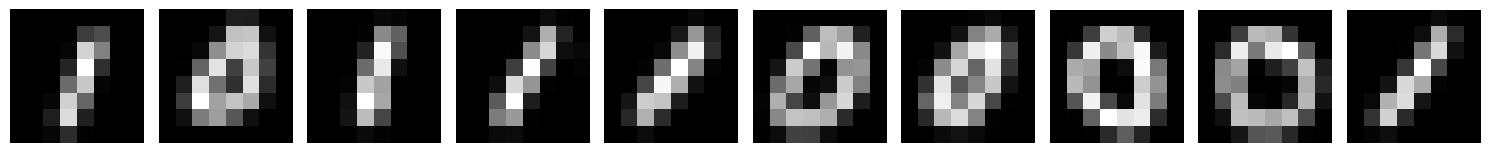

In [3]:
images = images_flat_raw.reshape(-1, 8, 8)
# Plot a few examples
num_examples = 10  # number of examples to display
fig, axes = plt.subplots(1, num_examples, figsize=(15, 2))

for i in range(num_examples):
    # Remove channel dimension if it exists (i.e., converting 8x8x1 to 8x8)
    img = images[i]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    
    axes[i].imshow(np.array(img), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
mean = jnp.mean(images_flat_raw)  # This calculates mean over all samples and pixels
std = jnp.std(images_flat_raw)    # This calculates std over all samples and pixels
images_flat = (images_flat_raw - mean) / std  # This normalizes the data

### Plot samples and marginal distributions

In [48]:
key = jr.PRNGKey(0)

key, subkey = jr.split(key)
t_forward = 10.
sigma_final = 1.0
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_final, samples0=images_flat, key=subkey)

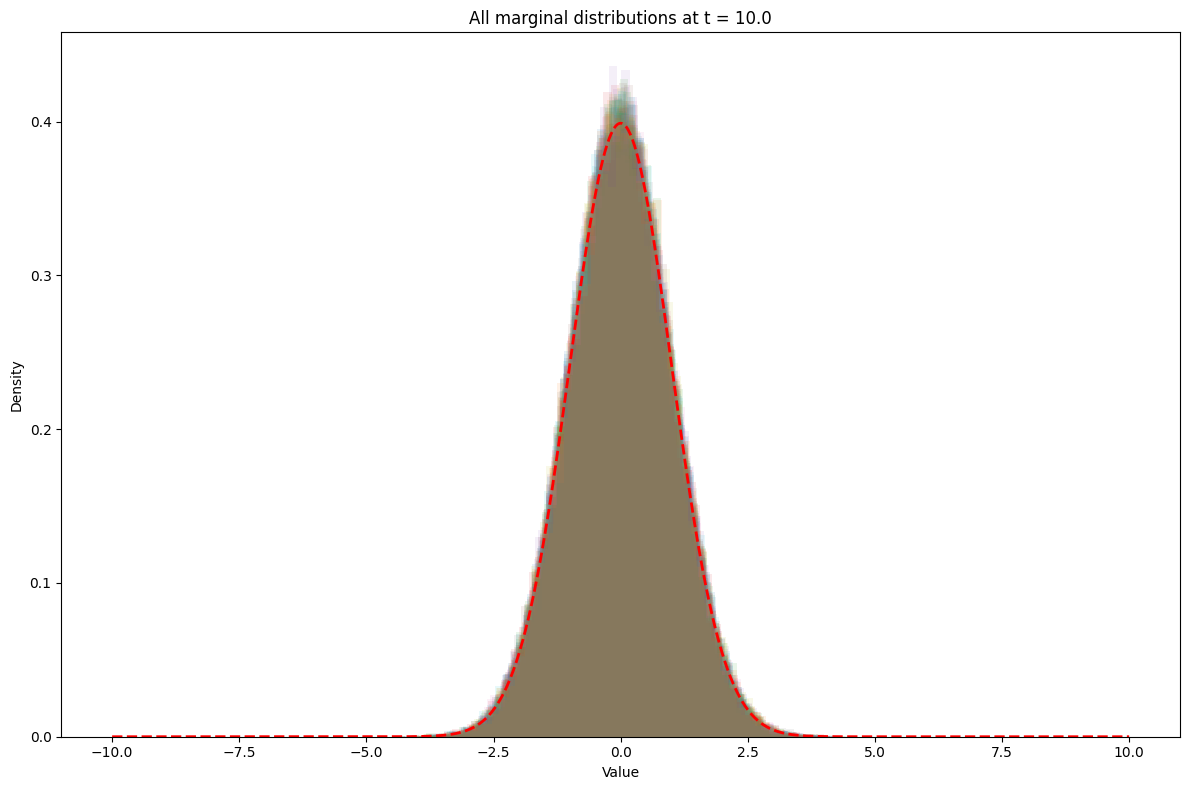

In [49]:
# Create a single plot for all marginal distributions
fig, ax = plt.subplots(figsize=(12, 8))

# Plot histogram for each dimension
for i in range(64):
    ax.hist(samples_t[:, i], bins=50, density=True, alpha=0.1, label=f'Dim {i}')

# Add Gaussian N(0,1) for comparison
x = jnp.linspace(-10, 10, 1000)
gaussian_pdf = (1 / jnp.sqrt(2 * jnp.pi*sigma_final**2)) * jnp.exp(-0.5 * x**2/sigma_final**2)
ax.plot(x, gaussian_pdf, 'r--', linewidth=2, label='Gaussian N(0,1)')

ax.set_title(f'All marginal distributions at t = {t_forward}')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
# ax.legend() # Commenting out as 64 legend entries would be too cluttered

plt.tight_layout()
plt.show()

### Define energy function of duffing oscillator network

In [7]:
def energy_self_oscillator(x, k_lin, k_duff):
    return 1 / 2 * k_lin * x**2 + 1 / 4 * k_duff * x**4

def energy_self_network(x, k_lin, k_duff):
    return jnp.sum(vmap(energy_self_oscillator)(x, k_lin, k_duff))


def energy_coupling_pair(x, y, c_lin, c_optomech):
    return c_lin * x * (x - y) + c_lin * y * (y - x) + c_optomech * (x**2) * y

def energy_coupling_network(x, c_lin, c_optomech, connectivity):
    # get contribution to total energy from each pair of oscillators
    
    def _coupling_energy_pair(x, c_lin, c_optomech, pair):
        # get energy of one pair of oscillators
        i, j = pair
        return energy_coupling_pair(x[i], x[j], c_lin, c_optomech)

    # get energy of all pairs of oscillators
    return jnp.sum(
        vmap(_coupling_energy_pair, in_axes=(None, 0, 0, 0))(
            x, c_lin, c_optomech, connectivity
        )
    )


def _energy_duffing_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity, k_b=1., T=1.):
    # returns energy of network of oscillators given input parameters
    return (
        energy_self_network(x, k_lin, k_duff) +
        energy_coupling_network(x, c_lin, c_optomech, connectivity)
    ) / (k_b * T)

Number of connections: 112
Connectivity matrix shape: (112, 2)

First few connections:
[[ 0  1]
 [ 0  8]
 [ 1  2]
 [ 1  9]
 [ 2  3]
 [ 2 10]
 [ 3  4]
 [ 3 11]
 [ 4  5]
 [ 4 12]
 [ 5  6]
 [ 5 13]
 [ 6  7]
 [ 6 14]
 [ 7 15]
 [ 8  9]
 [ 8 16]
 [ 9 10]
 [ 9 17]
 [10 11]
 [10 18]
 [11 12]
 [11 19]
 [12 13]
 [12 20]
 [13 14]
 [13 21]
 [14 15]
 [14 22]
 [15 23]
 [16 17]
 [16 24]
 [17 18]
 [17 25]
 [18 19]
 [18 26]
 [19 20]
 [19 27]
 [20 21]
 [20 28]
 [21 22]
 [21 29]
 [22 23]
 [22 30]
 [23 31]
 [24 25]
 [24 32]
 [25 26]
 [25 33]
 [26 27]
 [26 34]
 [27 28]
 [27 35]
 [28 29]
 [28 36]
 [29 30]
 [29 37]
 [30 31]
 [30 38]
 [31 39]
 [32 33]
 [32 40]
 [33 34]
 [33 41]
 [34 35]
 [34 42]
 [35 36]
 [35 43]
 [36 37]
 [36 44]
 [37 38]
 [37 45]
 [38 39]
 [38 46]
 [39 47]
 [40 41]
 [40 48]
 [41 42]
 [41 49]
 [42 43]
 [42 50]
 [43 44]
 [43 51]
 [44 45]
 [44 52]
 [45 46]
 [45 53]
 [46 47]
 [46 54]
 [47 55]
 [48 49]
 [48 56]
 [49 50]
 [49 57]
 [50 51]
 [50 58]
 [51 52]
 [51 59]
 [52 53]
 [52 60]
 [53 54]
 [53

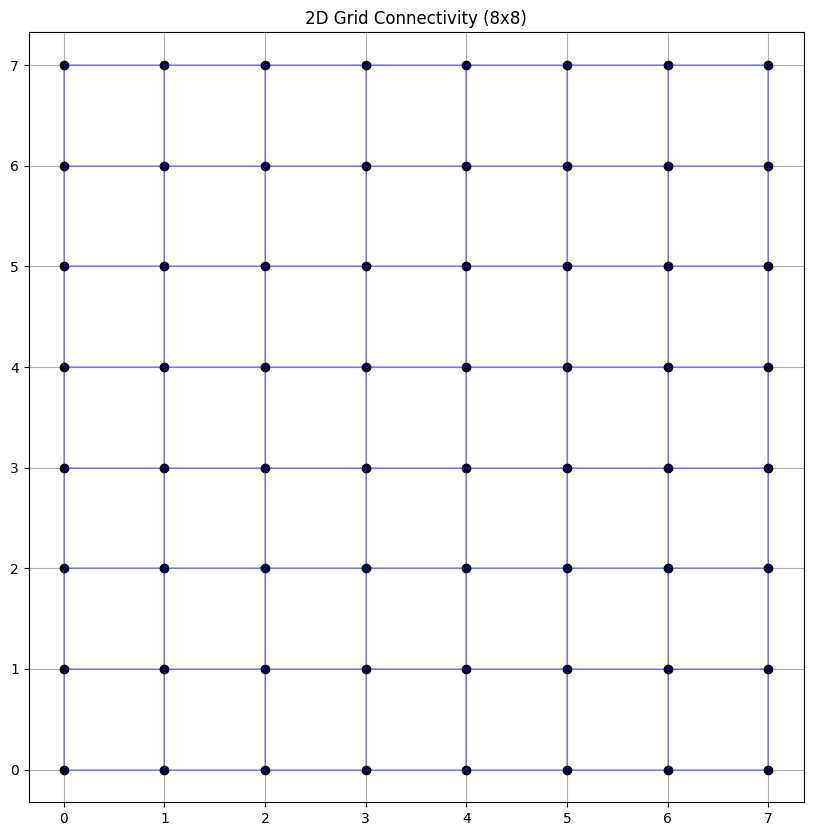

Number of connections: 112
Connectivity matrix shape: (112, 2)


In [8]:
N_osc = 64


# Create 2D grid connectivity for 8x8 oscillators
def create_2d_grid_connectivity(grid_size=jnp.sqrt(N_osc)):
    connections = []
    
    for i in range(grid_size):
        for j in range(grid_size):
            current = i * grid_size + j
            
            # Connect to right neighbor
            if j < grid_size - 1:
                connections.append([current, current + 1])
            
            # Connect to bottom neighbor
            if i < grid_size - 1:
                connections.append([current, current + grid_size])
    
    return jnp.array(connections)

def visualize_connectivity(connectivity, grid_size=8):
    """
    Visualize the connectivity pattern of the grid.
    
    Args:
        connectivity (jnp.ndarray): Connectivity matrix
        grid_size (int): Size of the square grid
    """    
    plt.figure(figsize=(10, 10))
    
    # Plot oscillators
    for i in range(grid_size):
        for j in range(grid_size):
            plt.plot(j, i, 'ko')
    
    # Plot connections
    for conn in connectivity:
        i1, j1 = divmod(conn[0], grid_size)
        i2, j2 = divmod(conn[1], grid_size)
        plt.plot([j1, j2], [i1, i2], 'b-', alpha=0.3)
    
    plt.grid(True)
    plt.axis('equal')
    plt.title(f'2D Grid Connectivity ({grid_size}x{grid_size})')
    plt.show()

# Create the connectivity matrix for 8x8 grid
connectivity = create_2d_grid_connectivity(grid_size=8)

# Print the number of connections
print(f"Number of connections: {len(connectivity)}")
print(f"Connectivity matrix shape: {connectivity.shape}")

# Example of first few connections
print("\nFirst few connections:")
print(connectivity)

visualize_connectivity(connectivity)
num_connections = connectivity.shape[0]
print(f"Number of connections: {num_connections}")
print(f"Connectivity matrix shape: {connectivity.shape}")


### Define initial parameters

In [9]:

k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
# connectivity = jnp.array([[0, 1]])

args_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)

flattened_args_initial, unflatten = flatten_util.ravel_pytree(args_initial)


### Bringe energy into correct form

In [10]:
def energy_duffing_network(x, flattened_args, connectivity):
    k_lin, k_duffing, c_lin, c_optomech = unflatten(flattened_args)
    return _energy_duffing_network(x, k_lin, k_duffing, c_lin, c_optomech, connectivity)
energy_fn = lambda x, flattened_args: energy_duffing_network(x, flattened_args, connectivity)

### Plot initial energy landscape

In [11]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

In [12]:
# Define filename for saving/loading parameters
n_time_steps = 50
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-20), jnp.log(t_forward), n_time_steps))
forward_time_pts = jnp.concatenate([jnp.array([0.]),forward_time_pts])

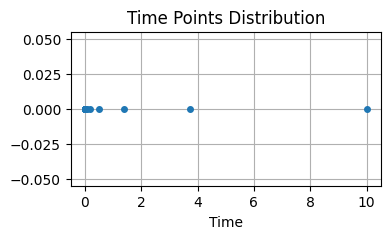

In [13]:
plt.figure(figsize=(4, 2))
plt.plot(forward_time_pts, jnp.zeros_like(forward_time_pts), 'o', markersize=4)
plt.xlabel('Time')
plt.ylabel('')
plt.title('Time Points Distribution')
plt.grid(True)
plt.show()

Optimization for time 0.0 with num epochs: 5000
Epoch 0
Loss: 790.9448
---
Epoch 100
Loss: -112738.7481
---
Epoch 200
Loss: -215554.9978
---
Epoch 300
Loss: -284794.6949
---
Epoch 400
Loss: -244063.4867
---
Epoch 500
Loss: -263991.2190
---
Epoch 600
Loss: -379737.9847
---
Epoch 700
Loss: -375872.0485
---
Epoch 800
Loss: -335210.0765
---
Epoch 900
Loss: -407680.4479
---
Epoch 1000
Loss: -392970.3560
---
Epoch 1100
Loss: -515381.6574
---
Epoch 1200
Loss: -397641.5424
---
Epoch 1300
Loss: -513199.3844
---
Epoch 1400
Loss: -494580.6199
---
Epoch 1500
Loss: -544987.6864
---
Epoch 1600
Loss: -469592.2260
---
Epoch 1700
Loss: -267714.8142
---
Epoch 1800
Loss: -539169.7708
---
Epoch 1900
Loss: -496772.9793
---
Epoch 2000
Loss: 493435.7529
---
Epoch 2100
Loss: -577757.0274
---
Epoch 2200
Loss: -554804.5535
---
Epoch 2300
Loss: -435366.2976
---
Epoch 2400
Loss: -359903.8562
---
Epoch 2500
Loss: -547307.9605
---
Epoch 2600
Loss: -603309.6341
---
Epoch 2700
Loss: -186585.6614
---
Epoch 2800
Loss: 

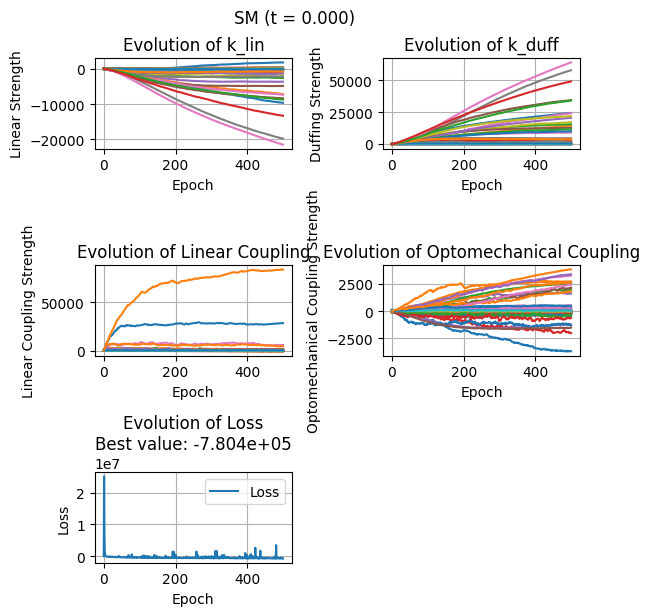

Optimization for time 9.999999999999992e-21 with num epochs: 1000
Epoch 0
Loss: -730374.9199
---
Epoch 100
Loss: -695389.0877
---
Epoch 200
Loss: -648363.0541
---
Epoch 300
Loss: -638632.6386
---
Epoch 400
Loss: -690513.6969
---
Epoch 500
Loss: -501984.3058
---
Epoch 600
Loss: -549157.1897
---
Epoch 700
Loss: -290095.9138
---
Epoch 800
Loss: 7120884.0364
---
Epoch 900
Loss: 191862.6024
---
Optimization for time 2.6826957952797236e-20 with num epochs: 1000
Epoch 0
Loss: 8826033.6297
---
Epoch 100
Loss: -708935.2400
---
Epoch 200
Loss: -618441.9969
---
Epoch 300
Loss: -524736.8203
---
Epoch 400
Loss: -653535.8146
---
Epoch 500
Loss: -682209.7971
---
Epoch 600
Loss: 802967.7792
---
Epoch 700
Loss: -708139.5851
---
Epoch 800
Loss: 943009.5576
---
Epoch 900
Loss: -666215.2789
---
Optimization for time 7.196856730011514e-20 with num epochs: 1000
Epoch 0
Loss: -720238.4209
---
Epoch 100
Loss: -687199.5904
---
Epoch 200
Loss: -681910.3996
---
Epoch 300
Loss: -708868.9319
---
Epoch 400
Loss: -5

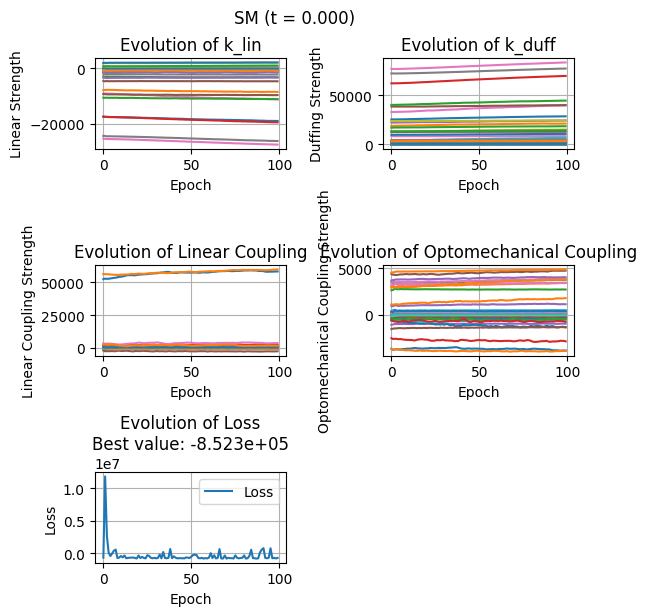

Optimization for time 1.930697728883248e-16 with num epochs: 1000
Epoch 0
Loss: -766047.9042
---
Epoch 100
Loss: -804184.5617
---
Epoch 200
Loss: -761972.7564
---
Epoch 300
Loss: 128362.3805
---
Epoch 400
Loss: -341275.4808
---
Epoch 500
Loss: -460580.8857
---
Epoch 600
Loss: 2765982.0854
---
Epoch 700
Loss: -792431.0150
---
Epoch 800
Loss: -804997.4677
---
Epoch 900
Loss: -763797.7017
---
Optimization for time 5.179474679231205e-16 with num epochs: 1000
Epoch 0
Loss: 1948109.0625
---
Epoch 100
Loss: -795689.4670
---
Epoch 200
Loss: -760592.1192
---
Epoch 300
Loss: -388330.2133
---
Epoch 400
Loss: 2393938.1472
---
Epoch 500
Loss: -778229.9426
---
Epoch 600
Loss: -732729.4500
---
Epoch 700
Loss: -779331.0705
---
Epoch 800
Loss: -777556.2354
---
Epoch 900
Loss: -744396.5720
---
Optimization for time 1.389495494373136e-15 with num epochs: 1000
Epoch 0
Loss: -745045.1467
---
Epoch 100
Loss: 9384394.0287
---
Epoch 200
Loss: -648647.1103
---
Epoch 300
Loss: 519889.5049
---
Epoch 400
Loss: -7

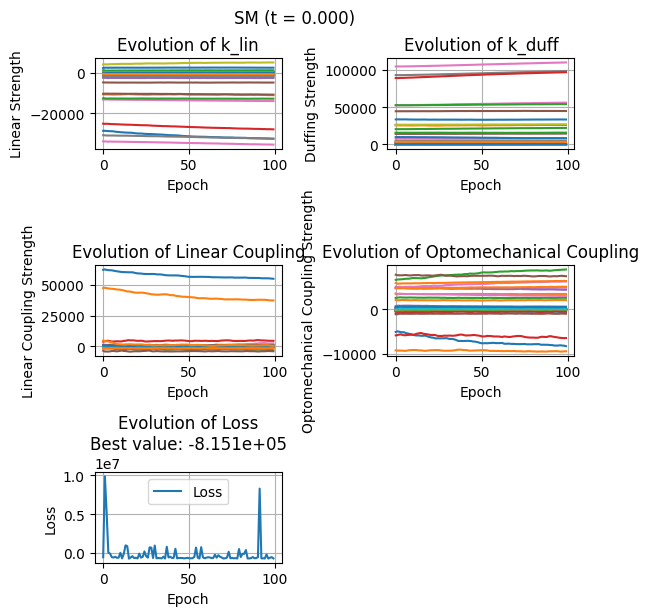

Optimization for time 3.727593720314935e-12 with num epochs: 1000
Epoch 0
Loss: -749932.1169
---
Epoch 100
Loss: -756121.0963
---
Epoch 200
Loss: 5940.5134
---
Epoch 300
Loss: 486807.4188
---
Epoch 400
Loss: -734890.0292
---
Epoch 500
Loss: -724847.2876
---
Epoch 600
Loss: -760772.2222
---
Epoch 700
Loss: -764504.2145
---
Epoch 800
Loss: -707339.5929
---
Epoch 900
Loss: -774223.8580
---
Optimization for time 9.99999999999995e-12 with num epochs: 1000
Epoch 0
Loss: -407856.8049
---
Epoch 100
Loss: 148755.2785
---
Epoch 200
Loss: -652423.0098
---
Epoch 300
Loss: -697276.1697
---
Epoch 400
Loss: -587913.7296
---
Epoch 500
Loss: -593426.6254
---
Epoch 600
Loss: 92861.2944
---
Epoch 700
Loss: 321515.3413
---
Epoch 800
Loss: -705103.4379
---
Epoch 900
Loss: -692681.8095
---
Optimization for time 2.6826957952797217e-11 with num epochs: 1000
Epoch 0
Loss: -632686.0329
---
Epoch 100
Loss: 343299.3497
---
Epoch 200
Loss: -687725.6310
---
Epoch 300
Loss: -647518.2969
---
Epoch 400
Loss: -709982.7

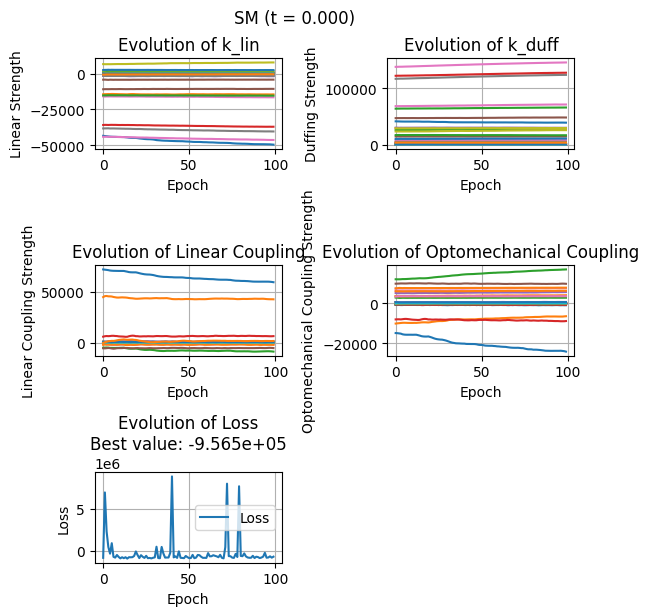

Optimization for time 7.196856730011507e-08 with num epochs: 1000
Epoch 0
Loss: -439829.2629
---
Epoch 100
Loss: -830403.2038
---
Epoch 200
Loss: -829139.3840
---
Epoch 300
Loss: -745789.0875
---
Epoch 400
Loss: -883251.8213
---
Epoch 500
Loss: -869838.2718
---
Epoch 600
Loss: -678527.8265
---
Epoch 700
Loss: 485329.0563
---
Epoch 800
Loss: -673239.2705
---
Epoch 900
Loss: -804812.9628
---
Optimization for time 1.930697728883243e-07 with num epochs: 1000
Epoch 0
Loss: -739483.1059
---
Epoch 100
Loss: -723648.6902
---
Epoch 200
Loss: -853438.7442
---
Epoch 300
Loss: -812717.6592
---
Epoch 400
Loss: -769837.5945
---
Epoch 500
Loss: -821541.9933
---
Epoch 600
Loss: 1197423.1729
---
Epoch 700
Loss: -824036.9815
---
Epoch 800
Loss: -828911.0157
---
Epoch 900
Loss: -692851.8779
---
Optimization for time 5.179474679231202e-07 with num epochs: 1000
Epoch 0
Loss: -784204.4271
---
Epoch 100
Loss: -706060.4338
---
Epoch 200
Loss: -678875.6679
---
Epoch 300
Loss: -775864.0944
---
Epoch 400
Loss: -

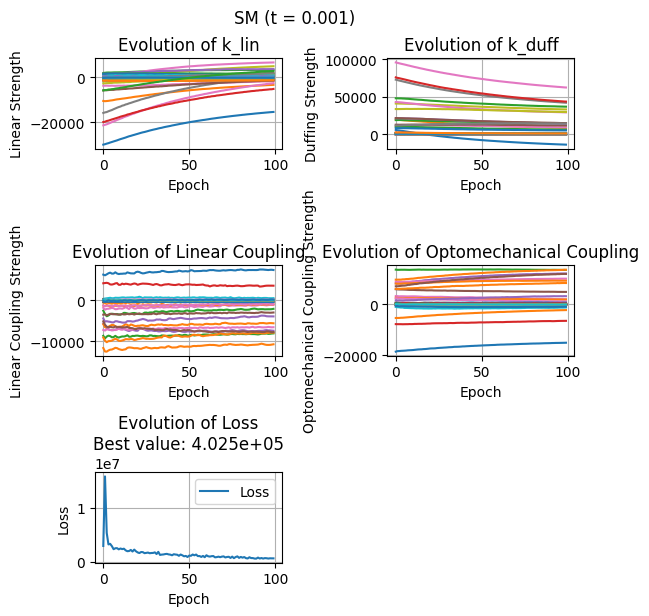

Optimization for time 0.0013894954943731335 with num epochs: 1000
Epoch 0
Loss: 1440208.3670
---
Epoch 100
Loss: 1363914.2222
---
Epoch 200
Loss: 974215.3366
---
Epoch 300
Loss: 372093.4927
---
Epoch 400
Loss: 308509.8299
---
Epoch 500
Loss: 306385.0425
---
Epoch 600
Loss: 288365.7467
---
Epoch 700
Loss: 373645.1154
---
Epoch 800
Loss: 245646.4378
---
Epoch 900
Loss: 239049.5088
---
Optimization for time 0.0037275937203149288 with num epochs: 1000
Epoch 0
Loss: 1221776.3989
---
Epoch 100
Loss: 896630.0701
---
Epoch 200
Loss: 605078.9216
---
Epoch 300
Loss: 419580.9961
---
Epoch 400
Loss: 289120.9818
---
Epoch 500
Loss: 227308.9506
---
Epoch 600
Loss: 159188.4891
---
Epoch 700
Loss: 142421.7778
---
Epoch 800
Loss: 92206.0910
---
Epoch 900
Loss: 80626.4978
---
Optimization for time 0.009999999999999969 with num epochs: 1000
Epoch 0
Loss: 565762.8343
---
Epoch 100
Loss: 103234.8484
---
Epoch 200
Loss: 17491.5225
---
Epoch 300
Loss: 1873.9252
---
Epoch 400
Loss: -240.1140
---
Epoch 500
Los

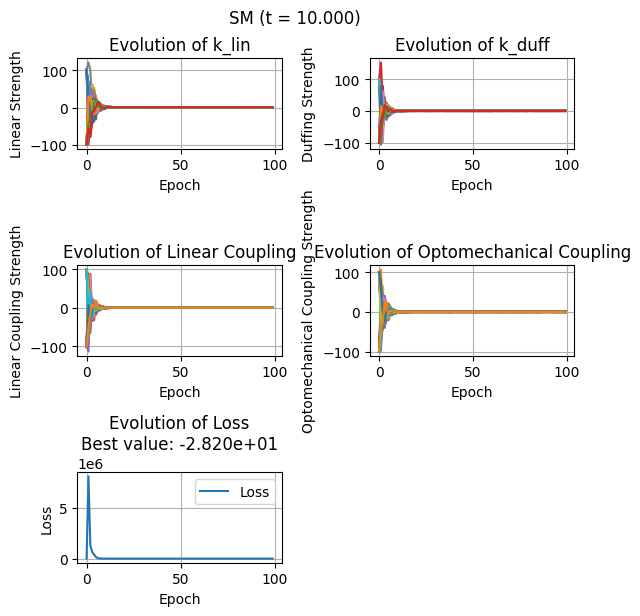

In [14]:
load_param_histories = True    
learning_rate = 100.
n_epochs_start = 5000
n_epochs_after_start = 1000
batch_size = 2*128
filename = f"out/MNIST/Labels_1_2_resol_8x8/{training_method}/params_history_means_t_forward_{t_forward}_n_timestes_{n_time_steps}_n_epochs_start_{n_epochs_start}_n_epochs_{n_epochs_after_start}_batch_size_{batch_size}_learning_rate_{learning_rate}.npy"
if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(filename)
else:
    # Setup optimization parameters
    mask = jnp.ones(flattened_args_initial.shape[0])


    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 1     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = flattened_args_initial

    # Loop over time points
    for t_idx, t_current in enumerate(forward_time_pts):
        print
        if t_idx == 0: 
            n_epochs = n_epochs_start
        else:
            n_epochs = n_epochs_after_start
        print(f"Optimization for time {t_current} with num epochs: {n_epochs}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_current,n_samples, D=1, sigma_final=sigma_final, samples0=images_flat, key=subkey)
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            decaying_learning_rate=True,
            transition_steps=n_epochs//100
        )
        
        _, best_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        k_lin_best, k_duff_best, c_lin_best, c_optomech_best = unflatten(best_params)
        current_params, _ = flatten_util.ravel_pytree(best_params)
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    N_connections=num_connections,
                    slicing=10,
                    title=f"{training_method} (t = {t_current:.3f})",
                    maximize=maximize,
                    labels_on=False
                )
                # Plot current energy landscape
                # plot_energy_and_distributions(
                #     energy_fn=energy_fn,
                #     param_list=[current_params],
                #     samples=samples_t,
                #     x1_range=(-1, 1),
                #     x2_range=(-1, 1),
                #     n_points=30,
                #     titles=[f"t = {t_forward:.3f}"],
                #     fontsize=16,
                #     sample_stride=1,
                #     suptitle=f"Energy Landscape at t = {t_forward:.3f}"
                # )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(filename, params_history_all_t)


### Smoothen and interpolate parameter evolution

In [77]:
def smooth_parameters(params, window_lengths = [5, 5, 5, 5, 5, 5], poly_orders = [3, 3, 3, 3, 3, 3]):
    if window_lengths is None:
        window_lengths = [10] * params.shape[1]
    if poly_orders is None:
        poly_orders = [3] * params.shape[1]
    """
    Smooths multiple parameter trajectories using Savitzky-Golay filter
    
    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories
        window_lengths: List/array of window lengths for each parameter dimension
        poly_orders: List/array of polynomial orders for each parameter dimension
    
    Returns:
        Array of shape (n_timesteps, n_params) containing smoothed parameter trajectories
    """
    n_params = params.shape[1]
    smoothed = []
    
    for i in range(n_params):
        print(i)
        # Ensure window length is odd and valid
        window_length = min(window_lengths[i], len(params) - (1 - len(params) % 2))
        if window_length % 2 == 0:
            window_length -= 1
            
        # Smooth using Savitzky-Golay filter
        smoothed.append(savgol_filter(params[:, i], window_length, poly_orders[i]))
    
    return jnp.column_stack(smoothed)


def interpolate_parameters(params, time_points):
    """
    Interpolates parameter trajectories using jnp.interp in a vectorized fashion.

    Args:
        params: Array of shape (n_timesteps, n_params) containing parameter trajectories.
        time_points: 1D array of shape (n_timesteps,) corresponding to the time points.

    Returns:
        A function that takes time points `t` (scalar or 1D array) and returns
        the interpolated parameters. For scalar `t`, the result is shape (n_params,);
        for vector `t`, the result is shape (len(t), n_params).
    """
    
    def _interpolator(t):
        # Transpose params to shape (n_params, n_timesteps) so that each row is a trajectory.
        # Use vmap to apply jnp.interp over each parameter trajectory.
        interpolated = jax.vmap(lambda param: jnp.interp(t, time_points, param))(params.T)
        # If t is an array, jnp.interp returns an array for each parameter, resulting in a
        # (n_params, len(t)) array. Transpose it so that each row corresponds to a time point.
        if jnp.ndim(t) > 0:
            return interpolated.T
        return interpolated

    return _interpolator


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

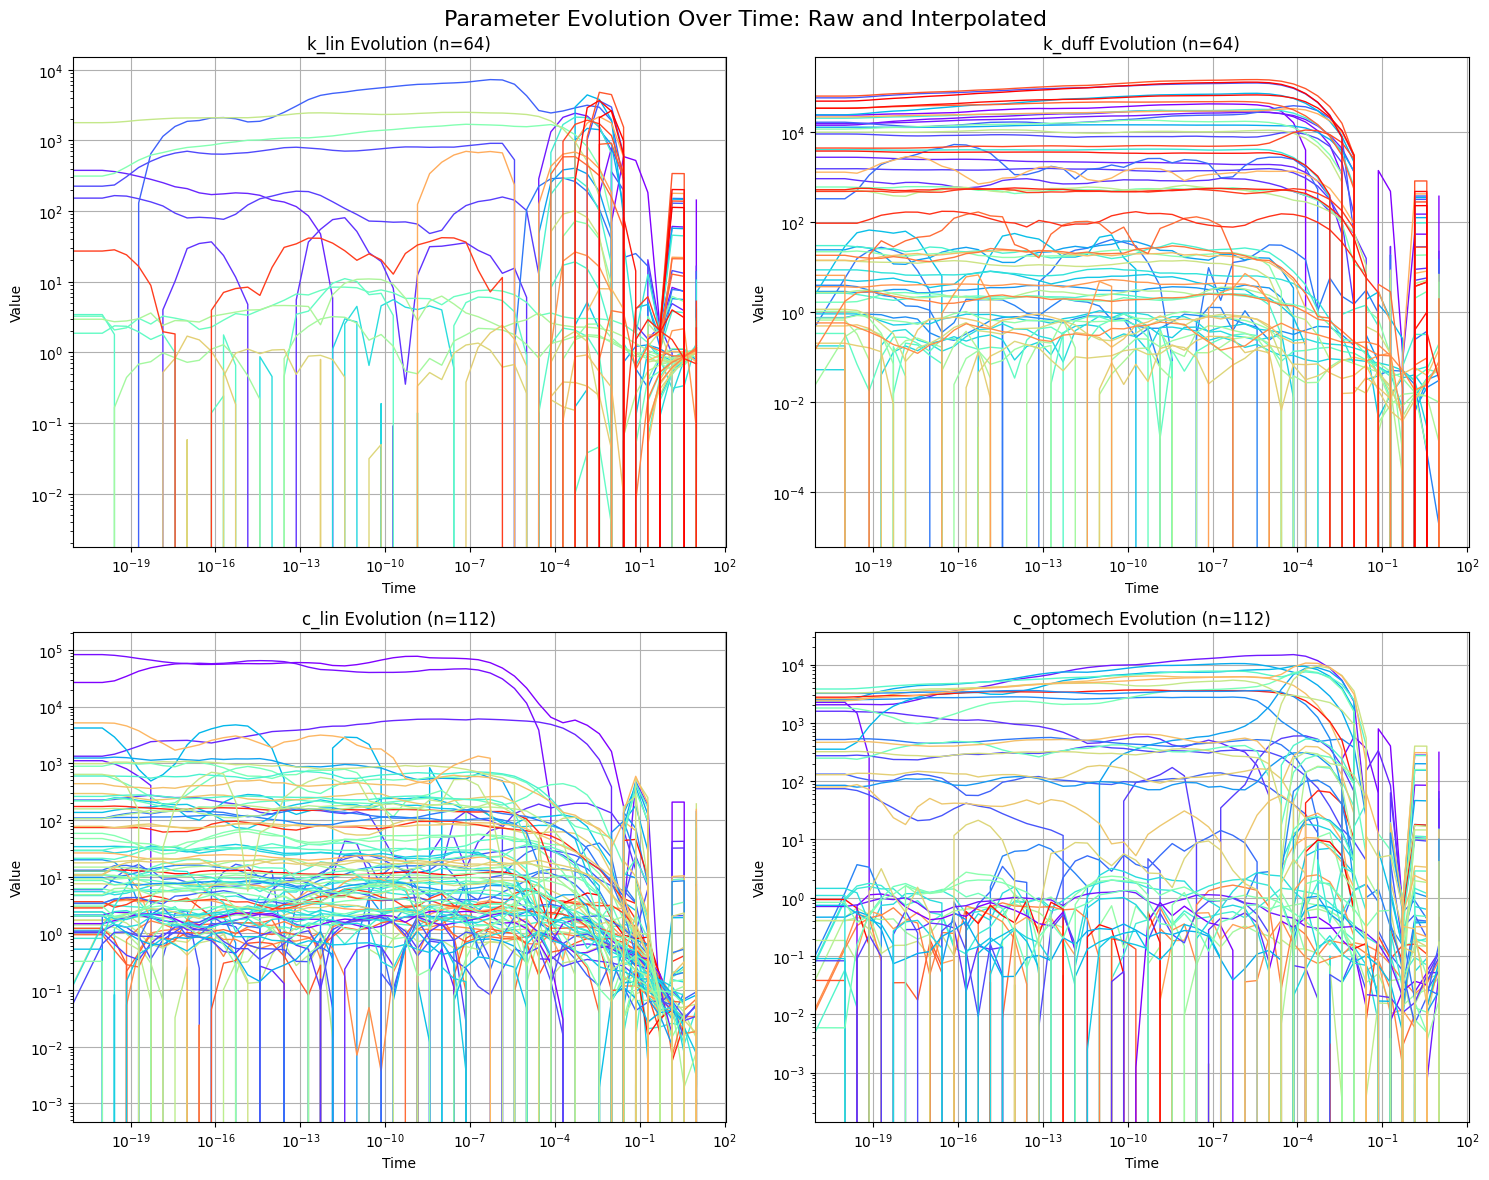

In [78]:
use_smoothed_params = True
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths=None, poly_orders=None)
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = forward_time_pts
# time_eval = jnp.linspace(forward_time_pts[0],0.1,200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = plt.cm.rainbow(np.linspace(0, 1, N_osc))  # Create color map based on number of oscillators

# Define parameter slices
param_slices = [
    slice(0, N_osc),           # k_lin
    slice(N_osc, 2*N_osc),     # k_duff
    slice(2*N_osc, 2*N_osc + num_connections),    # c_lin
    slice(2*N_osc + num_connections, 2*N_osc + 2*num_connections)  # c_optomech
]

# Plot for each parameter type
for ax, param_name, param_slice in zip(axes, param_names, param_slices):
    num_params = param_slice.stop - param_slice.start
    
    # Plot each parameter in the slice
    for i in range(num_params):
        param_idx = param_slice.start + i
        # Plot raw data (lighter)
        # ax.plot(forward_time_pts, params_history_all_t[:, param_idx], 
        #         color=colors[i % len(colors)], alpha=0.3)
        
        # Plot interpolated data (darker)
        ax.plot(time_eval, interpolated_params[:, param_idx], 
                color=colors[i % len(colors)], linewidth=1)
    
    ax.set_title(f'{param_name} Evolution (n={num_params})')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.set_yscale('log') 
    ax.set_xscale('log') 
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [17]:
forward_params = jnp.zeros_like(flattened_args_initial)
forward_params = forward_params.at[0:N_osc].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_final**2 * forward_params

In [18]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [21]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.0000001

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 2  # or any other number of trajectories you need
n_dimensions = N_osc  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0,
        rtol=1e-6,
        atol=1e-9
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)



0.00%|          | [00:00<?, ?%/s]
0.00%|          | [00:00<?, ?%/s]
0.00%|          | [00:00<?, ?%/s]
0.00%|          | [00:00<?, ?%/s]
0.00%|          | [00:00<?, ?%/s]
0.01%|          | [00:00<12:02,  7.23s/%]
0.01%|          | [00:00<14:50,  8.91s/%]
0.01%|          | [00:00<17:43, 10.63s/%]
0.01%|          | [00:00<17:43, 10.63s/%]
0.02%|          | [00:00<17:43, 10.63s/%]
0.02%|          | [00:00<17:43, 10.63s/%]
0.02%|          | [00:00<17:43, 10.63s/%]
0.02%|          | [00:00<17:43, 10.63s/%]
0.02%|          | [00:00<17:43, 10.63s/%]
0.03%|          | [00:00<11:06,  6.67s/%]
0.03%|          | [00:00<11:06,  6.67s/%]
0.03%|          | [00:00<11:06,  6.67s/%]
0.04%|          | [00:00<11:06,  6.67s/%]
0.04%|          | [00:00<11:06,  6.67s/%]
0.04%|          | [00:00<11:06,  6.67s/%]
0.04%|          | [00:00<11:06,  6.67s/%]
0.05%|          | [00:00<09:51,  5.92s/%]
0.05%|          | [00:00<09:51,  5.92s/%]
0.05%|          | [00:00<09:51,  5.92s/%]
0.06%|          | [00:00<09:51,

XlaRuntimeError: INTERNAL: Generated function failed: CpuCallback error: Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/asyncio/base_events.py", line 641, in run_forever
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/asyncio/base_events.py", line 1986, in _run_once
  File "/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/asyncio/ev